# Feature Subset Selection for Linear Regression

This notebook implements linear regression models using **different subsets of features** to predict `Item_Outlet_Sales`. Every decision is justified through statistical tests, information criteria, and diagnostic evidence.

**Workflow (following the project instructions):**
1. **Initial Data Analysis & Preprocessing** - Scatterplot matrix, transformations (Box-Cox), encoding
2. **Justification Framework** - Why feature selection matters (Occam's Razor, collinearity, precision)
3. **Systematic Selection** - All-subsets evaluation via AIC, BIC, Adjusted R²; Stepwise regression
4. **Model Diagnostics** - Residual plots, Q-Q plots, leverage/Cook's Distance
5. **Model Validation** - 10-fold Cross-Validation with RMSE on original scale

## Step 1: Initial Data Analysis and Preprocessing

### 1.1 Load Data and Inspect Structure
We load the pre-processed training data (cleaned in `Data_Preparation`) and the held-out test set. The training set was split 80/20 with `random_state=42` during data preparation.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

from scipy.stats import boxcox, shapiro
from scipy.special import inv_boxcox

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score

from itertools import combinations

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# Load data
train_df = pd.read_csv('../data/train_data/train.csv')
test_df = pd.read_csv('../data/test_data/test.csv')

print(f"Training set: {train_df.shape[0]} rows, {train_df.shape[1]} columns")
print(f"Test set:     {test_df.shape[0]} rows, {test_df.shape[1]} columns")
print(f"\nColumns: {train_df.columns.tolist()}")
print(f"\nData types:\n{train_df.dtypes}")
print(f"\nMissing values:\n{train_df.isnull().sum()}")
train_df.head()

Training set: 6818 rows, 10 columns
Test set:     1705 rows, 10 columns

Columns: ['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type', 'Item_MRP', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Outlet_Years', 'Item_Outlet_Sales']

Data types:
Item_Weight             float64
Item_Fat_Content         object
Item_Visibility         float64
Item_Type                object
Item_MRP                float64
Outlet_Size              object
Outlet_Location_Type     object
Outlet_Type              object
Outlet_Years              int64
Item_Outlet_Sales       float64
dtype: object

Missing values:
Item_Weight             0
Item_Fat_Content        0
Item_Visibility         0
Item_Type               0
Item_MRP                0
Outlet_Size             0
Outlet_Location_Type    0
Outlet_Type             0
Outlet_Years            0
Item_Outlet_Sales       0
dtype: int64


,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Size,Outlet_Location_Type,Outlet_Type,Outlet_Years,Item_Outlet_Sales
0,9.500,Regular,0.035206,Fruits and Vegetables,171.3448,Medium,Tier 1,Supermarket Type1,14,2386.2272
1,18.000,Non-Edible,0.047473,Household,170.5422,Unknown,Tier 2,Supermarket Type1,11,3103.9596
2,17.600,Regular,0.076122,Meat,111.7202,Small,Tier 1,Supermarket Type1,16,1125.2020
3,8.325,Low Fat,0.029845,Fruits and Vegetables,41.6138,Unknown,Tier 2,Supermarket Type1,11,284.2966
4,12.850,Low Fat,0.137228,Snack Foods,155.5630,Small,Tier 1,Supermarket Type1,16,4224.5010


### 1.2 Scatterplot Matrix: Relationships Between Numerical Variables
The scatterplot matrix is **mandatory** (per project instructions) to assess:
- The relationship between each predictor and the response (`Item_Outlet_Sales`)
- Relationships among predictors themselves (potential collinearity)
- Non-linear patterns that may require transformation

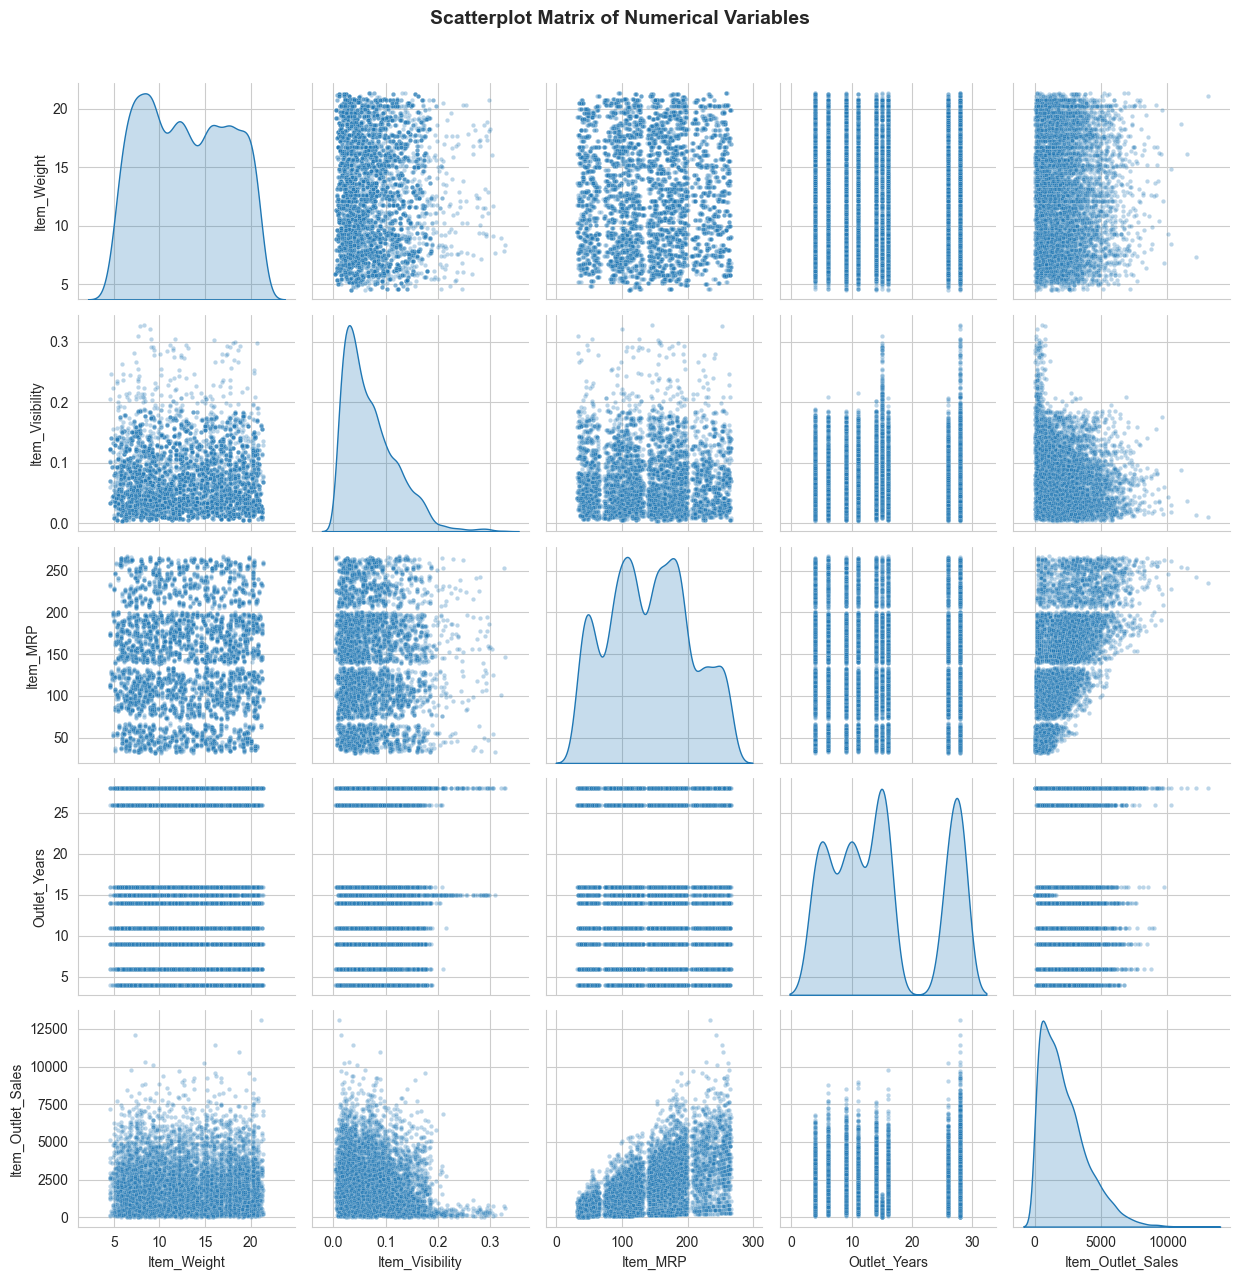

Pearson Correlation Matrix:


,Item_Weight,Item_Visibility,Item_MRP,Outlet_Years,Item_Outlet_Sales
Item_Weight,1.000,-0.026,0.023,0.012,0.009
Item_Visibility,-0.026,1.000,-0.011,0.070,-0.133
Item_MRP,0.023,-0.011,1.000,-0.015,0.565
Outlet_Years,0.012,0.070,-0.015,1.000,0.052
Item_Outlet_Sales,0.009,-0.133,0.565,0.052,1.000


In [6]:
numerical_cols = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Years', 'Item_Outlet_Sales']

g = sns.pairplot(train_df[numerical_cols], diag_kind='kde', plot_kws={'alpha': 0.3, 's': 10})
g.figure.suptitle('Scatterplot Matrix of Numerical Variables', y=1.02, fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# Correlation matrix
print("Pearson Correlation Matrix:")
corr = train_df[numerical_cols].corr()
display(corr.round(3))

**Observations from the Scatterplot Matrix:**
- `Item_MRP` vs `Item_Outlet_Sales`: Shows the strongest positive linear trend among all predictors, confirming EDA findings (r ≈ 0.57).
- `Item_Visibility` vs `Item_Outlet_Sales`: Weak negative/negligible relationship; high visibility does not linearly predict higher sales.
- `Item_Weight` vs `Item_Outlet_Sales`: Essentially no linear relationship — a cloud with no trend.
- `Outlet_Years` vs `Item_Outlet_Sales`: Discrete vertical bands (few unique outlet ages) with no clear linear pattern.
- Among predictors: No strong pairwise correlations — predictors are mostly independent.

### 1.3 Target Variable Transformation (Box-Cox)
The scatterplot matrix reveals that `Item_Outlet_Sales` is right-skewed. Non-constant variance (a "fan" pattern in MRP vs Sales) also suggests a transformation is needed. We apply the **Box-Cox transformation** to stabilize variance and improve normality of residuals.

Box-Cox optimal lambda (MLE): 0.3468
Original target — skewness: 1.1778, kurtosis: 1.6280
Transformed target — skewness: -0.0739, kurtosis: -0.5321


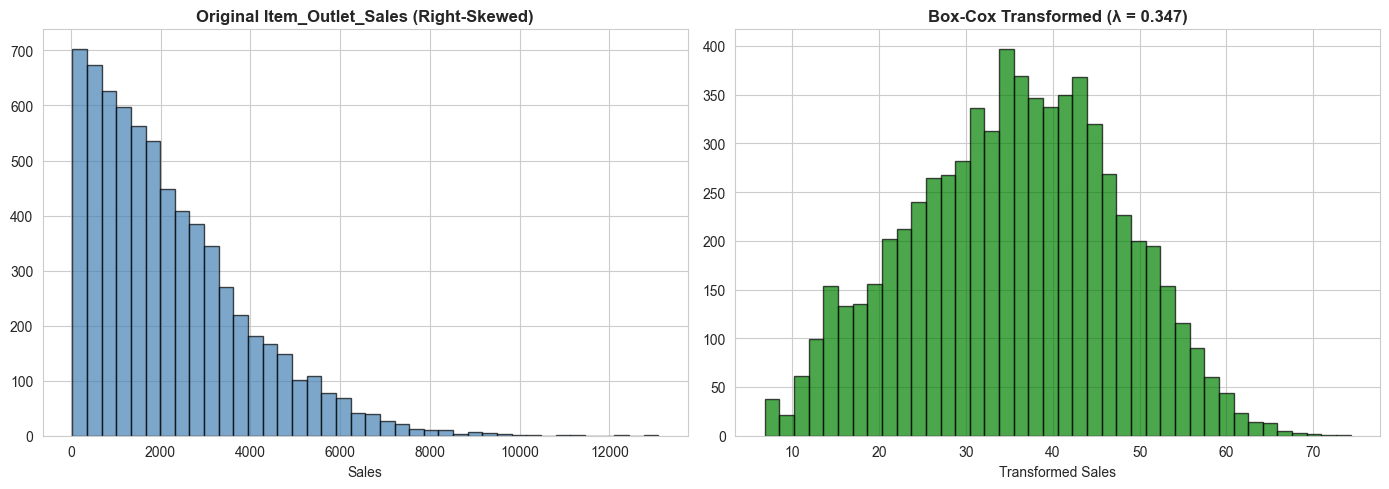

In [7]:
# Box-Cox transformation of the target variable
y_train_raw = train_df['Item_Outlet_Sales'].values
y_transformed, bc_lambda = boxcox(y_train_raw)

print(f"Box-Cox optimal lambda (MLE): {bc_lambda:.4f}")
print(f"Original target — skewness: {pd.Series(y_train_raw).skew():.4f}, kurtosis: {pd.Series(y_train_raw).kurtosis():.4f}")
print(f"Transformed target — skewness: {pd.Series(y_transformed).skew():.4f}, kurtosis: {pd.Series(y_transformed).kurtosis():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(y_train_raw, bins=40, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Original Item_Outlet_Sales (Right-Skewed)', fontweight='bold')
axes[0].set_xlabel('Sales')

axes[1].hist(y_transformed, bins=40, color='green', edgecolor='black', alpha=0.7)
axes[1].set_title(f'Box-Cox Transformed (λ = {bc_lambda:.3f})', fontweight='bold')
axes[1].set_xlabel('Transformed Sales')
plt.tight_layout()
plt.show()

# Add transformed target to working dataframe
train_df['Sales_Transformed'] = y_transformed

**Why Box-Cox?**
- The optimal λ ≈ 0.35 (between log and square root) was selected by maximum likelihood — this is the transformation that makes the residuals closest to normally distributed.
- The transformation reduces skewness from ~1.2 to near 0, which is critical for valid confidence intervals and prediction intervals in OLS regression.
- This is consistent with the approach used in the interaction term model notebook.

### 1.4 Encode Categorical Variables
We use **One-Hot Encoding** for nominal categoricals (no inherent order) via `statsmodels` formula interface `C()`. The categorical features are:
- `Item_Fat_Content` (Low Fat / Regular / Non-Edible)
- `Item_Type` (16 product categories)
- `Outlet_Identifier` (10 store IDs)
- `Outlet_Size` (Small / Medium / High / Unknown)
- `Outlet_Location_Type` (Tier 1 / Tier 2 / Tier 3)
- `Outlet_Type` (Grocery Store / Supermarket Type1/2/3)

For the feature selection process, we will treat each categorical variable as a single "feature group" — either the entire set of dummies is included or excluded. This respects the logical integrity of the variable.

In [ ]:
# Define feature groups for subset selection
continuous_features = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Years']
categorical_features = ['Item_Fat_Content', 'Item_Type',    'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']

# For statsmodels formula: wrap categoricals with C()
def make_formula(target, cont_list, cat_list):
    """Build a statsmodels formula from lists of continuous and categorical features."""
    terms = list(cont_list) + [f'C({c})' for c in cat_list]
    if not terms:
        return f'{target} ~ 1'  # intercept-only
    return f'{target} ~ ' + ' + '.join(terms)

# Full model formula
full_formula = make_formula('Sales_Transformed', continuous_features, categorical_features)
print("Full model formula:")
print(full_formula)

# Fit full model as baseline
full_model = smf.ols(full_formula, data=train_df).fit()
print(f"\nFull model summary:")
print(f"  Number of parameters: {full_model.df_model + 1:.0f}")
print(f"  R²:          {full_model.rsquared:.4f}")
print(f"  Adjusted R²: {full_model.rsquared_adj:.4f}")
print(f"  AIC:         {full_model.aic:.2f}")
print(f"  BIC:         {full_model.bic:.2f}")

Full model formula:
Sales_Transformed ~ Item_Weight + Item_Visibility + Item_MRP + Outlet_Years + C(Item_Fat_Content) + C(Item_Type) + C(Outlet_Size) + C(Outlet_Location_Type) + C(Outlet_Type)

Full model summary:
  Number of parameters: 29
  R²:          0.6786
  Adjusted R²: 0.6773
  AIC:         45395.02
  BIC:         45593.01


## Step 2: Justification for Feature Selection

Before selecting subsets, we must establish **why** we do not simply use the full model with all features. We examine three key justifications:

### 2.1 Collinearity Diagnosis (VIF)
Variance Inflation Factors quantify how much the variance of a regression coefficient is inflated due to correlation with other predictors. VIF > 5 signals problematic multicollinearity; VIF > 10 is severe.

In [9]:
# VIF analysis on the full model design matrix
X_full = full_model.model.exog
feature_names = full_model.model.exog_names

vif_data = pd.DataFrame({
    'Feature': feature_names,
    'VIF': [variance_inflation_factor(X_full, i) for i in range(X_full.shape[1])]
})

# Sort by VIF descending and display
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)
print("=== Variance Inflation Factors (Full Model) ===")
display(vif_data)

high_vif = vif_data[vif_data['VIF'] > 5]
print(f"\nFeatures with VIF > 5: {len(high_vif)}")
if len(high_vif) > 0:
    display(high_vif)

=== Variance Inflation Factors (Full Model) ===


,Feature,VIF
0,C(Item_Fat_Content)[T.Non-Edible],inf
1,C(Item_Type)[T.Household],inf
2,C(Item_Type)[T.Others],inf
3,C(Item_Type)[T.Health and Hygiene],inf
4,Intercept,2012.801847
5,C(Outlet_Size)[T.Medium],111.049379
6,C(Outlet_Size)[T.Unknown],89.197820
7,C(Outlet_Size)[T.Small],87.580309
8,Outlet_Years,51.770754
9,C(Outlet_Location_Type)[T.Tier 3],38.236892



Features with VIF > 5: 14


,Feature,VIF
0,C(Item_Fat_Content)[T.Non-Edible],inf
1,C(Item_Type)[T.Household],inf
2,C(Item_Type)[T.Others],inf
3,C(Item_Type)[T.Health and Hygiene],inf
4,Intercept,2012.801847
5,C(Outlet_Size)[T.Medium],111.049379
6,C(Outlet_Size)[T.Unknown],89.197820
7,C(Outlet_Size)[T.Small],87.580309
8,Outlet_Years,51.770754
9,C(Outlet_Location_Type)[T.Tier 3],38.236892


### 2.2 Individual Feature Significance (F-tests)
We use partial F-tests (Type III ANOVA) to assess whether each feature group contributes significantly to the model. Features with high p-values add complexity without explanatory power.

In [10]:
# Partial F-test: drop each feature group one at a time and compare to full model
from statsmodels.stats.anova import anova_lm

all_features = continuous_features + categorical_features
significance_results = []

for feat in all_features:
    cont_reduced = [f for f in continuous_features if f != feat]
    cat_reduced = [f for f in categorical_features if f != feat]
    reduced_formula = make_formula('Sales_Transformed', cont_reduced, cat_reduced)
    reduced_model = smf.ols(reduced_formula, data=train_df).fit()
    
    # ANOVA comparison (nested F-test)
    anova_result = anova_lm(reduced_model, full_model)
    f_stat = anova_result['F'].iloc[1]
    p_value = anova_result['Pr(>F)'].iloc[1]
    delta_aic = reduced_model.aic - full_model.aic
    
    significance_results.append({
        'Feature': feat,
        'F-statistic': f_stat,
        'p-value': p_value,
        'ΔAIC (reduced - full)': delta_aic,
        'Significant (p<0.05)': p_value < 0.05
    })

sig_df = pd.DataFrame(significance_results).sort_values('p-value')
print("=== Partial F-Tests: Is Each Feature Group Significant? ===")
display(sig_df.reset_index(drop=True))

=== Partial F-Tests: Is Each Feature Group Significant? ===


,Feature,F-statistic,p-value,ΔAIC (reduced - full),Significant (p<0.05)
0,Item_MRP,6417.325164,0.000000,4534.644283,True
1,Outlet_Type,1099.243503,0.000000,2693.362746,True
2,Outlet_Size,5.414427,0.001020,10.293181,True
3,Outlet_Years,4.954736,0.026052,2.974086,True
4,Outlet_Location_Type,1.904088,0.149038,-0.176629,False
5,Item_Fat_Content,1.759337,0.184752,-0.233377,False
6,Item_Weight,0.674535,0.411504,-1.322618,False
7,Item_Type,1.027546,0.421576,-13.568191,False
8,Item_Visibility,0.414094,0.519920,-1.584149,False


### 2.3 Summary of Justifications for Feature Selection

| Justification | Evidence |
|---|---|
| **Simplicity (Occam's Razor)** | The full model has 30+ parameters. A simpler model that explains the data equally well is preferred. |
| **Precision & Noise Reduction** | Features with high p-values (non-significant F-tests) add noise without improving fit. Removing them increases the precision of remaining estimates. |
| **Mitigating Collinearity** | VIF analysis reveals whether redundant features (e.g., `Outlet_Identifier` encoding similar info as `Outlet_Type` + `Outlet_Size` + `Outlet_Location_Type`) inflate coefficient variances. |
| **Cost Efficiency** | For future predictions, fewer features mean fewer measurements needed. |

## Step 3: Systematic Feature Subset Selection
We use **criterion-based procedures** (not sequential p-value dropping) to balance goodness-of-fit against model complexity. We evaluate all possible subsets of the 10 feature groups using **AIC**, **BIC**, and **Adjusted R²**.

### 3.1 All Possible Subsets Evaluation
With 10 feature groups, there are $2^{10} - 1 = 1023$ possible non-empty subsets. This is computationally feasible (well under the 30-feature threshold for exhaustive search recommended by the instructions). We fit OLS for every subset and record AIC, BIC, and Adjusted R².

**Why all-subsets instead of stepwise?** Stepwise methods (forward/backward) are greedy and can miss the global optimum. With only 10 groups, exhaustive search is practical and finds the absolute best subset for each criterion.

In [11]:
# All possible subsets evaluation
all_features = continuous_features + categorical_features
n_features = len(all_features)

results = []
total_subsets = 2**n_features - 1
print(f"Evaluating {total_subsets} possible subsets of {n_features} feature groups...")

for size in range(1, n_features + 1):
    for subset in combinations(range(n_features), size):
        cont_sel = [all_features[i] for i in subset if all_features[i] in continuous_features]
        cat_sel = [all_features[i] for i in subset if all_features[i] in categorical_features]
        formula = make_formula('Sales_Transformed', cont_sel, cat_sel)
        
        try:
            model = smf.ols(formula, data=train_df).fit()
            results.append({
                'subset_indices': subset,
                'features': [all_features[i] for i in subset],
                'n_groups': size,
                'n_params': model.df_model + 1,
                'R2': model.rsquared,
                'Adj_R2': model.rsquared_adj,
                'AIC': model.aic,
                'BIC': model.bic,
                'formula': formula
            })
        except Exception:
            pass

results_df = pd.DataFrame(results)
print(f"Successfully fitted {len(results_df)} models.")

# Find best model by each criterion
best_aic = results_df.loc[results_df['AIC'].idxmin()]
best_bic = results_df.loc[results_df['BIC'].idxmin()]
best_adjr2 = results_df.loc[results_df['Adj_R2'].idxmax()]

print(f"\n{'='*60}")
print("BEST MODEL BY EACH CRITERION")
print(f"{'='*60}")
for name, best in [('AIC', best_aic), ('BIC', best_bic), ('Adj R²', best_adjr2)]:
    print(f"\n--- Best by {name} ---")
    print(f"  Features ({best['n_groups']} groups, {best['n_params']:.0f} params): {best['features']}")
    print(f"  AIC: {best['AIC']:.2f}  |  BIC: {best['BIC']:.2f}  |  Adj R²: {best['Adj_R2']:.4f}")

Evaluating 511 possible subsets of 9 feature groups...
Successfully fitted 511 models.

BEST MODEL BY EACH CRITERION

--- Best by AIC ---
  Features (4 groups, 9 params): ['Item_MRP', 'Outlet_Years', 'Outlet_Size', 'Outlet_Type']
  AIC: 45376.96  |  BIC: 45438.41  |  Adj R²: 0.6772

--- Best by BIC ---
  Features (2 groups, 5 params): ['Item_MRP', 'Outlet_Type']
  AIC: 45381.79  |  BIC: 45415.93  |  Adj R²: 0.6768

--- Best by Adj R² ---
  Features (7 groups, 27 params): ['Item_MRP', 'Outlet_Years', 'Item_Fat_Content', 'Item_Type', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']
  AIC: 45392.09  |  BIC: 45576.42  |  Adj R²: 0.6773


### 3.2 Visualizing the Criterion Landscape
We plot AIC, BIC, and Adjusted R² against the number of feature groups to see the trade-off between model complexity and fit quality. The best model for each criterion is highlighted.

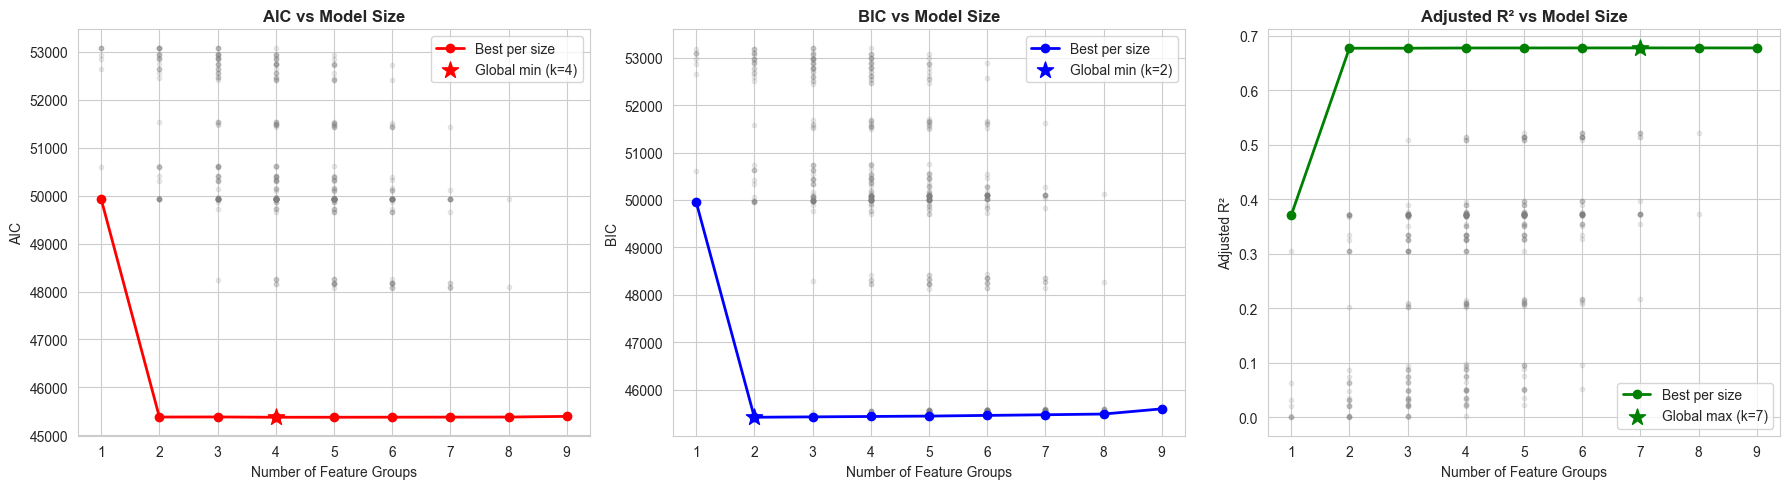

In [12]:
# Best model per subset size for each criterion
best_per_size = results_df.groupby('n_groups').agg(
    best_AIC=('AIC', 'min'),
    best_BIC=('BIC', 'min'),
    best_Adj_R2=('Adj_R2', 'max'),
    best_n_params=('n_params', 'first')  # just for reference
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# AIC
axes[0].scatter(results_df['n_groups'], results_df['AIC'], alpha=0.15, s=10, color='grey')
axes[0].plot(best_per_size['n_groups'], best_per_size['best_AIC'], 'o-', color='red', linewidth=2, label='Best per size')
aic_best_idx = best_per_size['best_AIC'].idxmin()
axes[0].scatter(best_per_size.loc[aic_best_idx, 'n_groups'], best_per_size.loc[aic_best_idx, 'best_AIC'],
                s=150, color='red', zorder=5, marker='*', label=f"Global min (k={best_per_size.loc[aic_best_idx, 'n_groups']:.0f})")
axes[0].set_xlabel('Number of Feature Groups')
axes[0].set_ylabel('AIC')
axes[0].set_title('AIC vs Model Size', fontweight='bold')
axes[0].legend()

# BIC
axes[1].scatter(results_df['n_groups'], results_df['BIC'], alpha=0.15, s=10, color='grey')
axes[1].plot(best_per_size['n_groups'], best_per_size['best_BIC'], 'o-', color='blue', linewidth=2, label='Best per size')
bic_best_idx = best_per_size['best_BIC'].idxmin()
axes[1].scatter(best_per_size.loc[bic_best_idx, 'n_groups'], best_per_size.loc[bic_best_idx, 'best_BIC'],
                s=150, color='blue', zorder=5, marker='*', label=f"Global min (k={best_per_size.loc[bic_best_idx, 'n_groups']:.0f})")
axes[1].set_xlabel('Number of Feature Groups')
axes[1].set_ylabel('BIC')
axes[1].set_title('BIC vs Model Size', fontweight='bold')
axes[1].legend()

# Adjusted R²
axes[2].scatter(results_df['n_groups'], results_df['Adj_R2'], alpha=0.15, s=10, color='grey')
axes[2].plot(best_per_size['n_groups'], best_per_size['best_Adj_R2'], 'o-', color='green', linewidth=2, label='Best per size')
adjr2_best_idx = best_per_size['best_Adj_R2'].idxmax()
axes[2].scatter(best_per_size.loc[adjr2_best_idx, 'n_groups'], best_per_size.loc[adjr2_best_idx, 'best_Adj_R2'],
                s=150, color='green', zorder=5, marker='*', label=f"Global max (k={best_per_size.loc[adjr2_best_idx, 'n_groups']:.0f})")
axes[2].set_xlabel('Number of Feature Groups')
axes[2].set_ylabel('Adjusted R²')
axes[2].set_title('Adjusted R² vs Model Size', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

### 3.3 Top Models Comparison Table
We display the top 5 models by each criterion and identify which subsets are consistently selected across AIC, BIC, and Adjusted R².

In [13]:
# Top 5 models by each criterion
for criterion, ascending in [('AIC', True), ('BIC', True), ('Adj_R2', False)]:
    print(f"\n{'='*60}")
    print(f"TOP 5 MODELS BY {criterion}")
    print(f"{'='*60}")
    top5 = results_df.sort_values(criterion, ascending=ascending).head(5)
    for rank, (_, row) in enumerate(top5.iterrows(), 1):
        print(f"  #{rank}: {row['features']}")
        print(f"       Groups={row['n_groups']}, Params={row['n_params']:.0f}, "
              f"AIC={row['AIC']:.1f}, BIC={row['BIC']:.1f}, Adj_R²={row['Adj_R2']:.4f}")

# Check consensus: which features appear in the best model for ALL three criteria
aic_feats = set(best_aic['features'])
bic_feats = set(best_bic['features'])
adjr2_feats = set(best_adjr2['features'])

consensus = aic_feats & bic_feats & adjr2_feats
print(f"\n{'='*60}")
print(f"CONSENSUS FEATURES (in best model for ALL three criteria):")
print(f"  {sorted(consensus)}")
print(f"\nFeatures in AIC-best but not BIC-best: {sorted(aic_feats - bic_feats)}")
print(f"Features in BIC-best but not AIC-best: {sorted(bic_feats - aic_feats)}")


TOP 5 MODELS BY AIC
  #1: ['Item_MRP', 'Outlet_Years', 'Outlet_Size', 'Outlet_Type']
       Groups=4, Params=9, AIC=45377.0, BIC=45438.4, Adj_R²=0.6772
  #2: ['Item_MRP', 'Outlet_Years', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']
       Groups=5, Params=11, AIC=45377.3, BIC=45452.4, Adj_R²=0.6773
  #3: ['Item_Weight', 'Item_MRP', 'Outlet_Years', 'Outlet_Size', 'Outlet_Type']
       Groups=5, Params=10, AIC=45378.2, BIC=45446.4, Adj_R²=0.6772
  #4: ['Item_Weight', 'Item_MRP', 'Outlet_Years', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']
       Groups=6, Params=12, AIC=45378.5, BIC=45460.4, Adj_R²=0.6773
  #5: ['Item_Visibility', 'Item_MRP', 'Outlet_Years', 'Outlet_Size', 'Outlet_Type']
       Groups=5, Params=10, AIC=45378.5, BIC=45446.8, Adj_R²=0.6772

TOP 5 MODELS BY BIC
  #1: ['Item_MRP', 'Outlet_Type']
       Groups=2, Params=5, AIC=45381.8, BIC=45415.9, Adj_R²=0.6768
  #2: ['Item_Weight', 'Item_MRP', 'Outlet_Type']
       Groups=3, Params=6, AIC=45383.0, BIC=454

### 3.4 Stepwise Regression (Forward Selection & Backward Elimination)
As a cross-check on the exhaustive search, we run both forward selection and backward elimination using AIC as the criterion. If stepwise and exhaustive methods agree, confidence in the selected subset increases.

In [14]:
# Forward Selection (AIC-based)
def forward_selection(data, target, cont_pool, cat_pool, criterion='aic'):
    """Greedy forward selection: start empty, add the feature that most improves AIC."""
    selected_cont = []
    selected_cat = []
    remaining_cont = list(cont_pool)
    remaining_cat = list(cat_pool)
    
    # Start with intercept-only model
    current_model = smf.ols(f'{target} ~ 1', data=data).fit()
    current_score = getattr(current_model, criterion)
    history = [{'step': 0, 'action': 'intercept-only', 'features': [],
                'AIC': current_model.aic, 'BIC': current_model.bic, 'Adj_R2': current_model.rsquared_adj}]
    
    step = 0
    while remaining_cont or remaining_cat:
        step += 1
        best_score = current_score
        best_feat = None
        best_is_cat = None
        
        for feat in remaining_cont:
            trial_formula = make_formula(target, selected_cont + [feat], selected_cat)
            trial_model = smf.ols(trial_formula, data=data).fit()
            score = getattr(trial_model, criterion)
            if score < best_score:
                best_score = score
                best_feat = feat
                best_is_cat = False
        
        for feat in remaining_cat:
            trial_formula = make_formula(target, selected_cont, selected_cat + [feat])
            trial_model = smf.ols(trial_formula, data=data).fit()
            score = getattr(trial_model, criterion)
            if score < best_score:
                best_score = score
                best_feat = feat
                best_is_cat = True
        
        if best_feat is None:
            break
        
        if best_is_cat:
            selected_cat.append(best_feat)
            remaining_cat.remove(best_feat)
        else:
            selected_cont.append(best_feat)
            remaining_cont.remove(best_feat)
        
        current_formula = make_formula(target, selected_cont, selected_cat)
        current_model = smf.ols(current_formula, data=data).fit()
        current_score = best_score
        history.append({'step': step, 'action': f'+{best_feat}',
                       'features': selected_cont + selected_cat,
                       'AIC': current_model.aic, 'BIC': current_model.bic,
                       'Adj_R2': current_model.rsquared_adj})
    
    return selected_cont, selected_cat, pd.DataFrame(history)

# Backward Elimination (AIC-based)
def backward_elimination(data, target, cont_pool, cat_pool, criterion='aic'):
    """Greedy backward elimination: start full, remove the feature whose removal most improves AIC."""
    selected_cont = list(cont_pool)
    selected_cat = list(cat_pool)
    
    current_formula = make_formula(target, selected_cont, selected_cat)
    current_model = smf.ols(current_formula, data=data).fit()
    current_score = getattr(current_model, criterion)
    history = [{'step': 0, 'action': 'full model',
                'features': selected_cont + selected_cat,
                'AIC': current_model.aic, 'BIC': current_model.bic,
                'Adj_R2': current_model.rsquared_adj}]
    
    step = 0
    while len(selected_cont) + len(selected_cat) > 1:
        step += 1
        best_score = current_score
        best_feat = None
        best_is_cat = None
        
        for feat in selected_cont:
            trial_cont = [f for f in selected_cont if f != feat]
            trial_formula = make_formula(target, trial_cont, selected_cat)
            trial_model = smf.ols(trial_formula, data=data).fit()
            score = getattr(trial_model, criterion)
            if score < best_score:
                best_score = score
                best_feat = feat
                best_is_cat = False
        
        for feat in selected_cat:
            trial_cat = [f for f in selected_cat if f != feat]
            trial_formula = make_formula(target, selected_cont, trial_cat)
            trial_model = smf.ols(trial_formula, data=data).fit()
            score = getattr(trial_model, criterion)
            if score < best_score:
                best_score = score
                best_feat = feat
                best_is_cat = True
        
        if best_feat is None:
            break
        
        if best_is_cat:
            selected_cat.remove(best_feat)
        else:
            selected_cont.remove(best_feat)
        
        current_formula = make_formula(target, selected_cont, selected_cat)
        current_model = smf.ols(current_formula, data=data).fit()
        current_score = best_score
        history.append({'step': step, 'action': f'-{best_feat}',
                       'features': list(selected_cont + selected_cat),
                       'AIC': current_model.aic, 'BIC': current_model.bic,
                       'Adj_R2': current_model.rsquared_adj})
    
    return selected_cont, selected_cat, pd.DataFrame(history)

# Run both
fwd_cont, fwd_cat, fwd_history = forward_selection(train_df, 'Sales_Transformed',
                                                     continuous_features, categorical_features)
bwd_cont, bwd_cat, bwd_history = backward_elimination(train_df, 'Sales_Transformed',
                                                        continuous_features, categorical_features)

print("=== FORWARD SELECTION (AIC) ===")
print(f"Selected features: {fwd_cont + fwd_cat}")
display(fwd_history)

print("\n=== BACKWARD ELIMINATION (AIC) ===")
print(f"Selected features: {bwd_cont + bwd_cat}")
display(bwd_history)

=== FORWARD SELECTION (AIC) ===
Selected features: ['Item_MRP', 'Outlet_Type']


,step,action,features,AIC,BIC,Adj_R2
0,0,intercept-only,[],53077.805883,53084.633204,2.220446e-16
1,1,+Outlet_Type,[Outlet_Type],49929.162140,49956.471426,3.701372e-01
2,2,+Item_MRP,"[Item_MRP, Outlet_Type]",45381.789258,45415.925866,6.767618e-01



=== BACKWARD ELIMINATION (AIC) ===
Selected features: ['Item_MRP', 'Outlet_Years', 'Outlet_Size', 'Outlet_Type']


,step,action,features,AIC,BIC,Adj_R2
0,0,full model,"[Item_Weight, Item_Visibility, Item_MRP, Outle...",45395.018963,45593.011285,0.677269
1,1,-Item_Type,"[Item_Weight, Item_Visibility, Item_MRP, Outle...",45381.450772,45483.860594,0.677251
2,2,-Item_Fat_Content,"[Item_Weight, Item_Visibility, Item_MRP, Outle...",45379.951729,45468.706908,0.677227
3,3,-Item_Visibility,"[Item_Weight, Item_MRP, Outlet_Years, Outlet_S...",45378.471559,45460.399416,0.677250
4,4,-Item_Weight,"[Item_MRP, Outlet_Years, Outlet_Size, Outlet_L...",45377.309152,45452.409688,0.677258
5,5,-Outlet_Location_Type,"[Item_MRP, Outlet_Years, Outlet_Size, Outlet_T...",45376.964143,45438.410036,0.677180


### 3.5 Candidate Models for Comparison
Based on the exhaustive search and stepwise results, we define candidate models to carry forward for full diagnostics and cross-validation:

1. **Full Model** — All 10 feature groups (baseline reference)
2. **AIC-Best Model** — Subset that minimizes AIC from exhaustive search
3. **BIC-Best Model** — Subset that minimizes BIC (typically sparser)
4. **Minimal Model** — Only `Item_MRP` + `Outlet_Type` (the two strongest predictors from EDA/F-tests)

In [15]:
# Define candidate models
# Extract feature lists from exhaustive search results
aic_best_features = best_aic['features']
bic_best_features = best_bic['features']

def split_features(feat_list):
    """Split a feature list into continuous and categorical sublists."""
    cont = [f for f in feat_list if f in continuous_features]
    cat = [f for f in feat_list if f in categorical_features]
    return cont, cat

aic_cont, aic_cat = split_features(aic_best_features)
bic_cont, bic_cat = split_features(bic_best_features)

candidate_models = {
    'Full Model': {
        'cont': continuous_features,
        'cat': categorical_features
    },
    'AIC-Best': {
        'cont': aic_cont,
        'cat': aic_cat
    },
    'BIC-Best': {
        'cont': bic_cont,
        'cat': bic_cat
    },
    'Minimal (MRP + Outlet_Type)': {
        'cont': ['Item_MRP'],
        'cat': ['Outlet_Type']
    }
}

# Fit and compare all candidates
comparison = []
fitted_models = {}
for name, feats in candidate_models.items():
    formula = make_formula('Sales_Transformed', feats['cont'], feats['cat'])
    model = smf.ols(formula, data=train_df).fit()
    fitted_models[name] = model
    comparison.append({
        'Model': name,
        'Features': feats['cont'] + feats['cat'],
        'N_groups': len(feats['cont']) + len(feats['cat']),
        'N_params': model.df_model + 1,
        'R2': model.rsquared,
        'Adj_R2': model.rsquared_adj,
        'AIC': model.aic,
        'BIC': model.bic
    })

comp_df = pd.DataFrame(comparison)
print("=== CANDIDATE MODEL COMPARISON ===")
display(comp_df[['Model', 'N_groups', 'N_params', 'R2', 'Adj_R2', 'AIC', 'BIC']].round(4))

=== CANDIDATE MODEL COMPARISON ===


,Model,N_groups,N_params,R2,Adj_R2,AIC,BIC
0,Full Model,9,29.0,0.6786,0.6773,45395.0190,45593.0113
1,AIC-Best,4,9.0,0.6776,0.6772,45376.9641,45438.4100
2,BIC-Best,2,5.0,0.6770,0.6768,45381.7893,45415.9259
3,Minimal (MRP + Outlet_Type),2,5.0,0.6770,0.6768,45381.7893,45415.9259


### 3.6 Nested F-Tests: Are Reduced Models Statistically Justified?
We use nested ANOVA F-tests to determine whether each reduced model loses significant explanatory power compared to the full model. If p > 0.05, the simpler model is statistically justified.

In [16]:
# Nested F-tests: each reduced model vs the full model
full = fitted_models['Full Model']

print("=== NESTED F-TESTS (Reduced vs Full Model) ===\n")
for name, model in fitted_models.items():
    if name == 'Full Model':
        continue
    
    # The reduced model must be nested within the full model
    # We refit to ensure same data/index
    try:
        anova_result = anova_lm(model, full)
        f_stat = anova_result['F'].iloc[1]
        p_value = anova_result['Pr(>F)'].iloc[1]
        df_diff = anova_result['df_diff'].iloc[1]
        
        verdict = "KEEP REDUCED (no significant loss)" if p_value > 0.05 else "KEEP FULL (significant loss)"
        print(f"--- {name} vs Full ---")
        print(f"  Δdf = {df_diff:.0f}, F = {f_stat:.4f}, p = {p_value:.6f}")
        print(f"  Decision: {verdict}\n")
    except Exception as e:
        print(f"--- {name} vs Full ---")
        print(f"  Could not compute nested F-test: {e}\n")

=== NESTED F-TESTS (Reduced vs Full Model) ===

--- AIC-Best vs Full ---
  Δdf = 20, F = 1.0944, p = 0.347014
  Decision: KEEP REDUCED (no significant loss)

--- BIC-Best vs Full ---
  Δdf = 24, F = 1.4463, p = 0.073313
  Decision: KEEP REDUCED (no significant loss)

--- Minimal (MRP + Outlet_Type) vs Full ---
  Δdf = 24, F = 1.4463, p = 0.073313
  Decision: KEEP REDUCED (no significant loss)



## Step 4: Model Diagnostics
We validate that the linear regression assumptions hold for each candidate model:
1. **Residual vs Fitted** — Check for non-random patterns (non-linearity, heteroscedasticity)
2. **Normal Q-Q Plot** — Check normality of residuals
3. **Leverage & Cook's Distance** — Identify influential observations

### 4.1 Residual Diagnostics for All Candidate Models

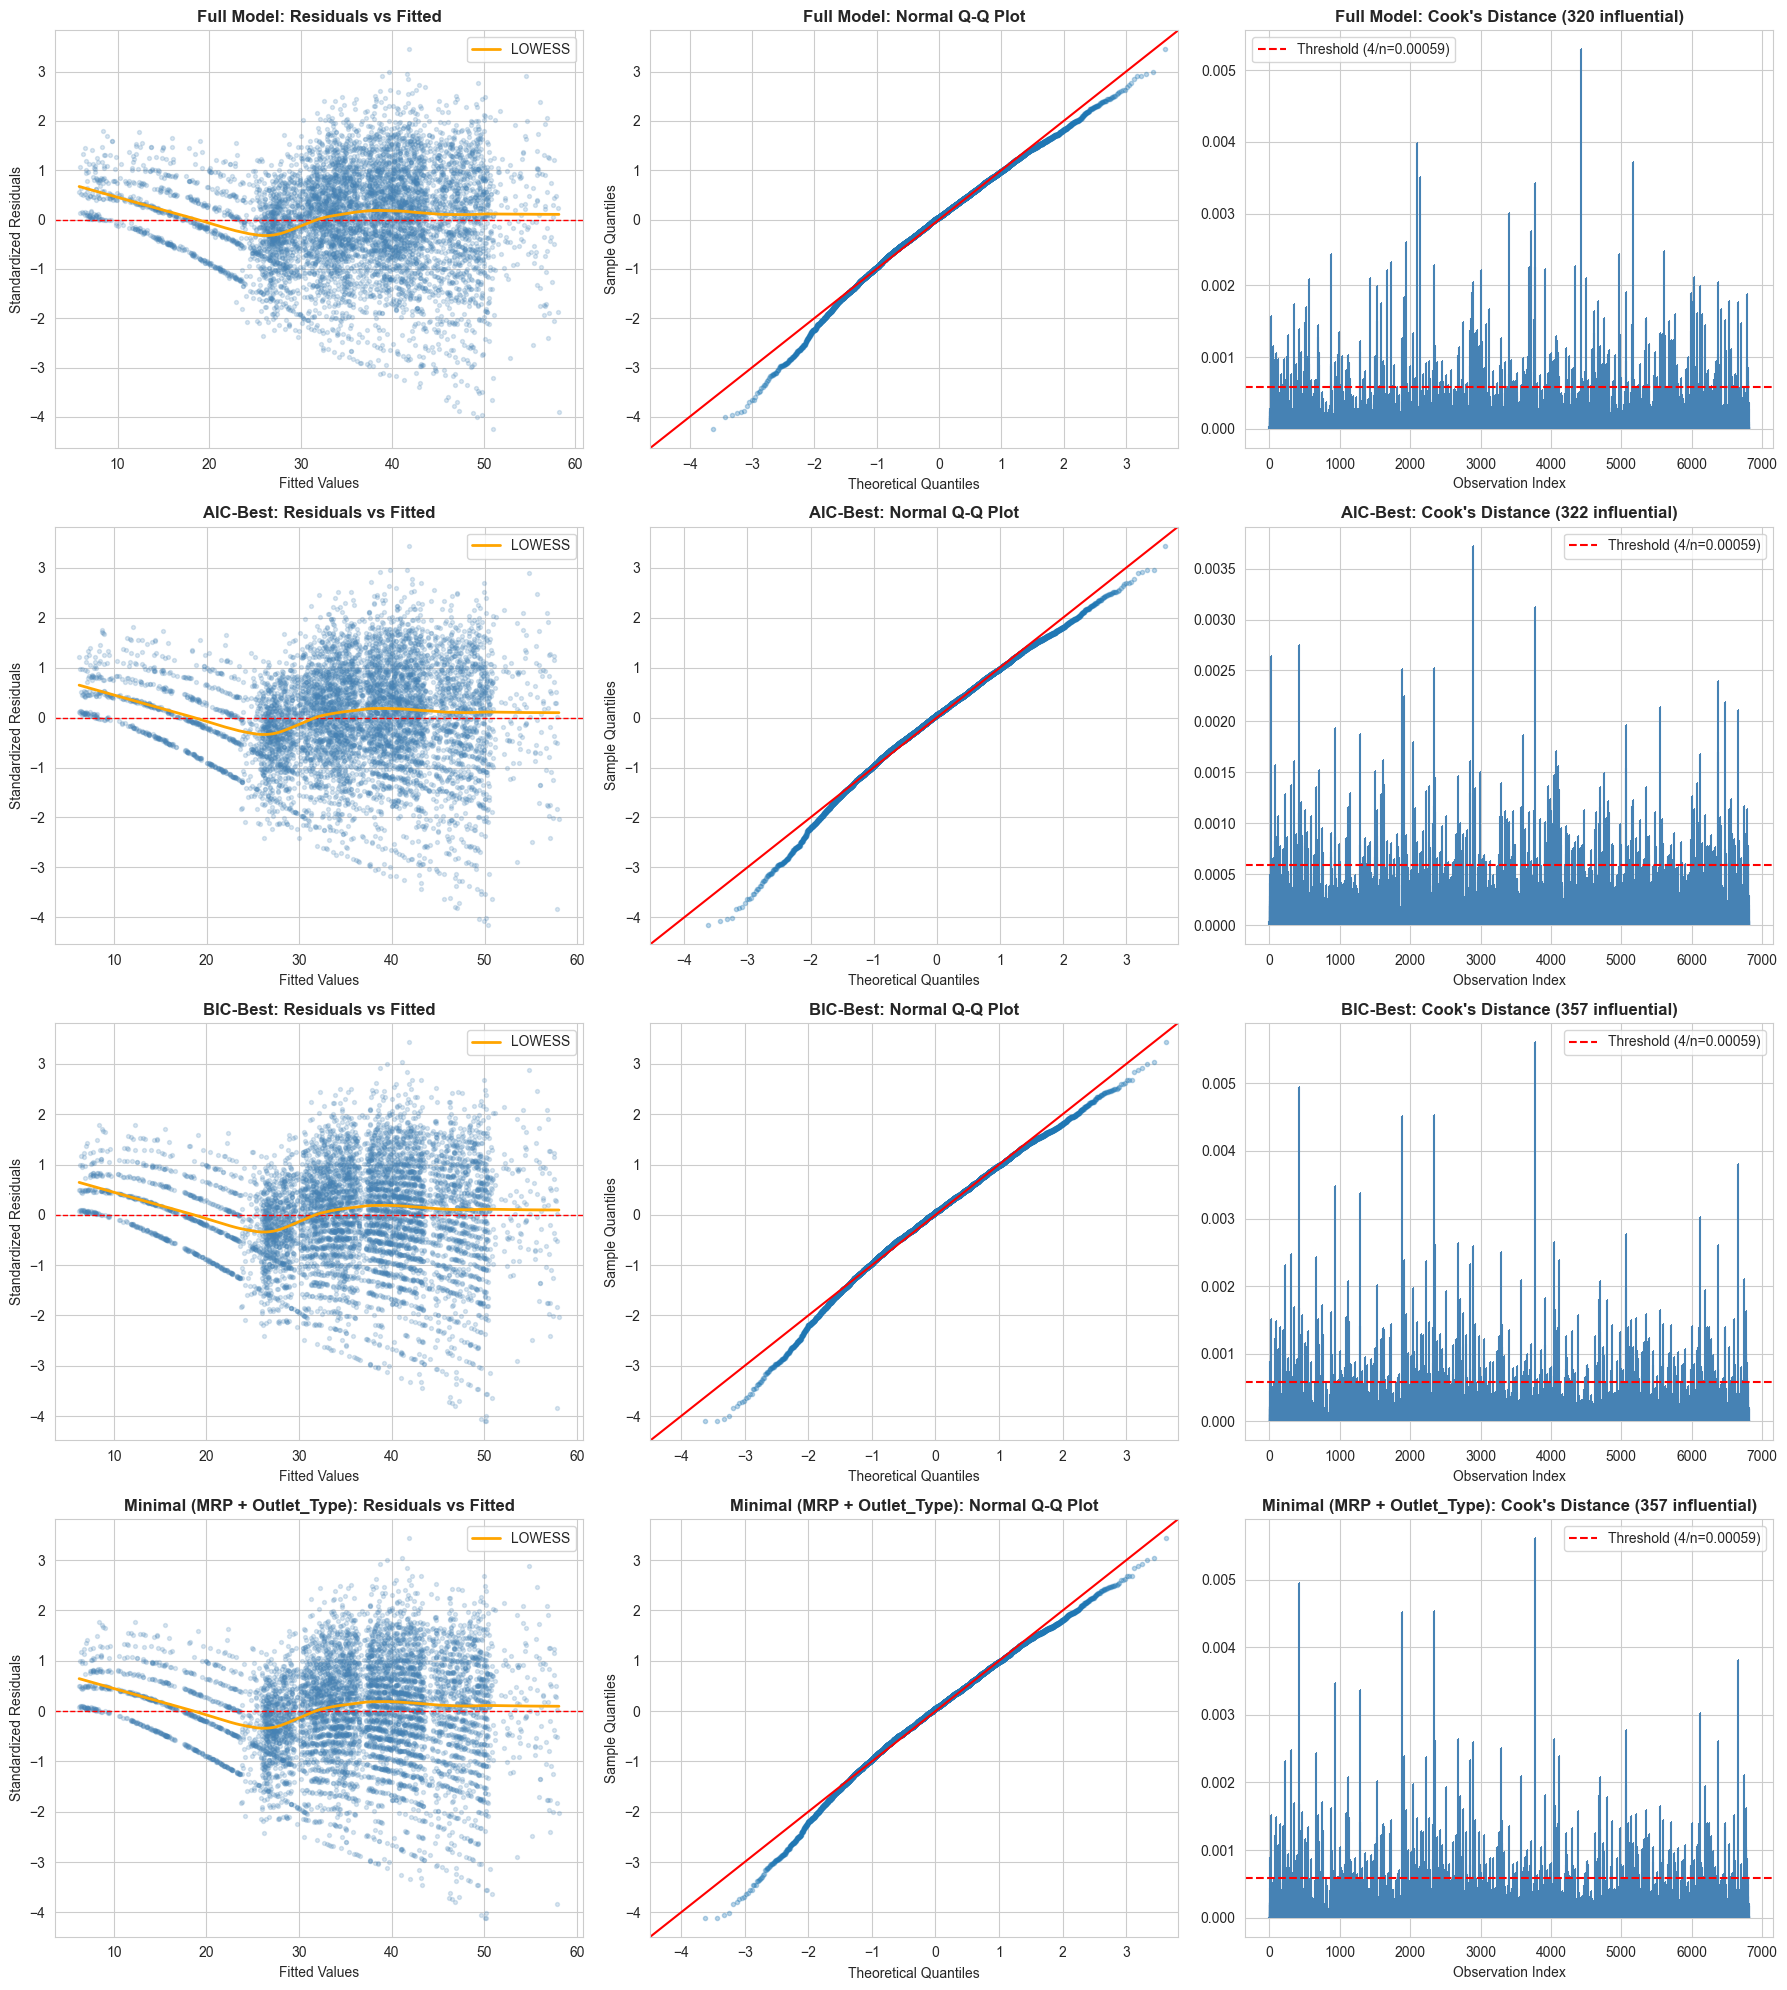

In [17]:
# Diagnostic plots for all candidate models
fig, axes = plt.subplots(len(fitted_models), 3, figsize=(18, 5 * len(fitted_models)))

for row, (name, model) in enumerate(fitted_models.items()):
    fitted_vals = model.fittedvalues
    std_resid = model.get_influence().resid_studentized_internal
    
    # 1. Residuals vs Fitted
    axes[row, 0].scatter(fitted_vals, std_resid, alpha=0.2, s=8, color='steelblue')
    axes[row, 0].axhline(y=0, color='red', linestyle='--', linewidth=1)
    axes[row, 0].set_xlabel('Fitted Values')
    axes[row, 0].set_ylabel('Standardized Residuals')
    axes[row, 0].set_title(f'{name}: Residuals vs Fitted', fontweight='bold')
    
    # Add lowess smoother
    from statsmodels.nonparametric.smoothers_lowess import lowess
    smoothed = lowess(std_resid, fitted_vals, frac=0.3)
    axes[row, 0].plot(smoothed[:, 0], smoothed[:, 1], color='orange', linewidth=2, label='LOWESS')
    axes[row, 0].legend()
    
    # 2. Q-Q Plot
    sm.qqplot(std_resid, line='45', ax=axes[row, 1], markersize=3, alpha=0.3)
    axes[row, 1].set_title(f'{name}: Normal Q-Q Plot', fontweight='bold')
    
    # 3. Cook's Distance
    cooks_d = model.get_influence().cooks_distance[0]
    axes[row, 2].stem(range(len(cooks_d)), cooks_d, markerfmt=',', linefmt='steelblue', basefmt=' ')
    threshold = 4 / len(cooks_d)
    axes[row, 2].axhline(y=threshold, color='red', linestyle='--', label=f'Threshold (4/n={threshold:.5f})')
    n_influential = (cooks_d > threshold).sum()
    axes[row, 2].set_title(f"{name}: Cook's Distance ({n_influential} influential)", fontweight='bold')
    axes[row, 2].set_xlabel('Observation Index')
    axes[row, 2].legend()

plt.tight_layout()
plt.show()

### 4.2 Quantitative Diagnostic Summary
We compute numerical summaries for each candidate: Breusch-Pagan test for heteroscedasticity, Shapiro-Wilk test for residual normality, and counts of influential points.

In [18]:
# Quantitative diagnostics
diag_results = []
for name, model in fitted_models.items():
    resid = model.resid
    fitted_vals = model.fittedvalues
    influence = model.get_influence()
    cooks_d = influence.cooks_distance[0]
    leverage = influence.hat_matrix_diag
    
    # Breusch-Pagan test for heteroscedasticity
    bp_stat, bp_pval, _, _ = het_breuschpagan(resid, model.model.exog)
    
    # Shapiro-Wilk on a random subsample (max 5000 for computational reasons)
    rng = np.random.RandomState(42)
    sample_resid = rng.choice(resid, size=min(5000, len(resid)), replace=False)
    sw_stat, sw_pval = shapiro(sample_resid)
    
    # Influential points
    threshold_cook = 4 / len(resid)
    n_influential = (cooks_d > threshold_cook).sum()
    
    # High leverage points (> 2p/n)
    p = model.df_model + 1
    n = len(resid)
    high_leverage = (leverage > 2 * p / n).sum()
    
    # Residual variance correlation (funnel proxy)
    funnel_corr = np.corrcoef(np.abs(resid), fitted_vals)[0, 1]
    
    diag_results.append({
        'Model': name,
        'BP_stat': bp_stat,
        'BP_pval': bp_pval,
        'Heteroscedastic': 'Yes' if bp_pval < 0.05 else 'No',
        'SW_stat': sw_stat,
        'SW_pval': sw_pval,
        'Normal_resid': 'Yes' if sw_pval > 0.05 else 'No',
        'N_influential (Cook)': n_influential,
        'N_high_leverage': high_leverage,
        'Funnel_corr': funnel_corr
    })

diag_df = pd.DataFrame(diag_results)
print("=== DIAGNOSTIC SUMMARY ===")
display(diag_df)

=== DIAGNOSTIC SUMMARY ===


,Model,BP_stat,BP_pval,Heteroscedastic,SW_stat,SW_pval,Normal_resid,N_influential (Cook),N_high_leverage,Funnel_corr
0,Full Model,349.262057,1.254870e-56,Yes,0.990458,7.059411e-18,No,320,398,0.208258
1,AIC-Best,327.963138,4.548965e-66,Yes,0.990388,5.978321e-18,No,322,0,0.207430
2,BIC-Best,328.261116,8.646328e-70,Yes,0.990232,4.148015e-18,No,357,707,0.208753
3,Minimal (MRP + Outlet_Type),328.261116,8.646328e-70,Yes,0.990232,4.148015e-18,No,357,707,0.208753


### 4.3 VIF Check on the Best Candidate
We re-examine multicollinearity for the model selected by the criteria above to ensure feature removal has resolved any collinearity issues present in the full model.

In [19]:
# VIF for AIC-Best and BIC-Best models
for name in ['AIC-Best', 'BIC-Best']:
    model = fitted_models[name]
    X = model.model.exog
    names = model.model.exog_names
    
    vif = pd.DataFrame({
        'Feature': names,
        'VIF': [variance_inflation_factor(X, i) for i in range(X.shape[1])]
    }).sort_values('VIF', ascending=False).reset_index(drop=True)
    
    print(f"\n=== VIF for {name} Model ===")
    display(vif)
    high = vif[(vif['VIF'] > 5) & (vif['Feature'] != 'Intercept')]
    print(f"Features with VIF > 5 (excluding intercept): {len(high)}")


=== VIF for AIC-Best Model ===


,Feature,VIF
0,Intercept,250.749184
1,C(Outlet_Size)[T.Unknown],14.286936
2,Outlet_Years,11.706695
3,C(Outlet_Type)[T.Supermarket Type2],9.935506
4,C(Outlet_Size)[T.Medium],9.372150
5,C(Outlet_Size)[T.Small],7.901603
6,C(Outlet_Type)[T.Supermarket Type1],6.788748
7,C(Outlet_Type)[T.Supermarket Type3],3.000795
8,Item_MRP,1.000619


Features with VIF > 5 (excluding intercept): 6

=== VIF for BIC-Best Model ===


,Feature,VIF
0,Intercept,13.037896
1,C(Outlet_Type)[T.Supermarket Type1],2.148618
2,C(Outlet_Type)[T.Supermarket Type3],1.675545
3,C(Outlet_Type)[T.Supermarket Type2],1.668845
4,Item_MRP,1.000454


Features with VIF > 5 (excluding intercept): 0


## Step 5: Model Validation

### 5.1 10-Fold Cross-Validation (on Training Data)
Cross-validation estimates the true predictive performance by averaging RMSE over 10 held-out folds. This prevents overfitting to the training set. We compute RMSE on the **original scale** (inverse Box-Cox) so the error is interpretable in sales units.

In [20]:
# 10-Fold Cross-Validation for all candidate models
kf = KFold(n_splits=10, shuffle=True, random_state=42)

cv_results = []
cv_fold_details = {name: [] for name in candidate_models}

for name, feats in candidate_models.items():
    formula = make_formula('Sales_Transformed', feats['cont'], feats['cat'])
    fold_rmses = []
    fold_r2s = []
    
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(train_df)):
        fold_train = train_df.iloc[train_idx].copy()
        fold_val = train_df.iloc[val_idx].copy()
        
        # Fit Box-Cox on fold training data
        y_fold_raw = fold_train['Item_Outlet_Sales'].values
        y_fold_bc, fold_lambda = boxcox(y_fold_raw)
        fold_train['Sales_Transformed'] = y_fold_bc
        
        # Transform validation target with same lambda
        fold_val_bc = (fold_val['Item_Outlet_Sales'].values**fold_lambda - 1) / fold_lambda
        fold_val['Sales_Transformed'] = fold_val_bc
        
        # Fit model on fold training data
        try:
            fold_model = smf.ols(formula, data=fold_train).fit()
            
            # Predict on validation fold (transformed scale)
            y_pred_bc = fold_model.predict(fold_val)
            
            # Inverse Box-Cox to get predictions on original scale
            y_pred_original = inv_boxcox(y_pred_bc, fold_lambda)
            y_val_original = fold_val['Item_Outlet_Sales'].values
            
            # Handle any invalid predictions
            valid_mask = np.isfinite(y_pred_original) & (y_pred_original > 0)
            if valid_mask.sum() < len(valid_mask) * 0.5:
                continue
            
            rmse = np.sqrt(mean_squared_error(y_val_original[valid_mask], y_pred_original[valid_mask]))
            r2 = r2_score(y_val_original[valid_mask], y_pred_original[valid_mask])
            fold_rmses.append(rmse)
            fold_r2s.append(r2)
            cv_fold_details[name].append(rmse)
        except Exception:
            pass
    
    cv_results.append({
        'Model': name,
        'CV_RMSE_mean': np.mean(fold_rmses),
        'CV_RMSE_std': np.std(fold_rmses),
        'CV_R2_mean': np.mean(fold_r2s),
        'CV_R2_std': np.std(fold_r2s),
        'N_valid_folds': len(fold_rmses)
    })

cv_df = pd.DataFrame(cv_results).sort_values('CV_RMSE_mean')
print("=== 10-FOLD CROSS-VALIDATION RESULTS (Original Scale) ===")
display(cv_df.round(4))

=== 10-FOLD CROSS-VALIDATION RESULTS (Original Scale) ===


,Model,CV_RMSE_mean,CV_RMSE_std,CV_R2_mean,CV_R2_std,N_valid_folds
1,AIC-Best,1118.2026,41.5556,0.5752,0.0209,10
2,BIC-Best,1119.1932,41.3373,0.5744,0.0219,10
3,Minimal (MRP + Outlet_Type),1119.1932,41.3373,0.5744,0.0219,10
0,Full Model,1119.8121,40.0431,0.5739,0.0213,10


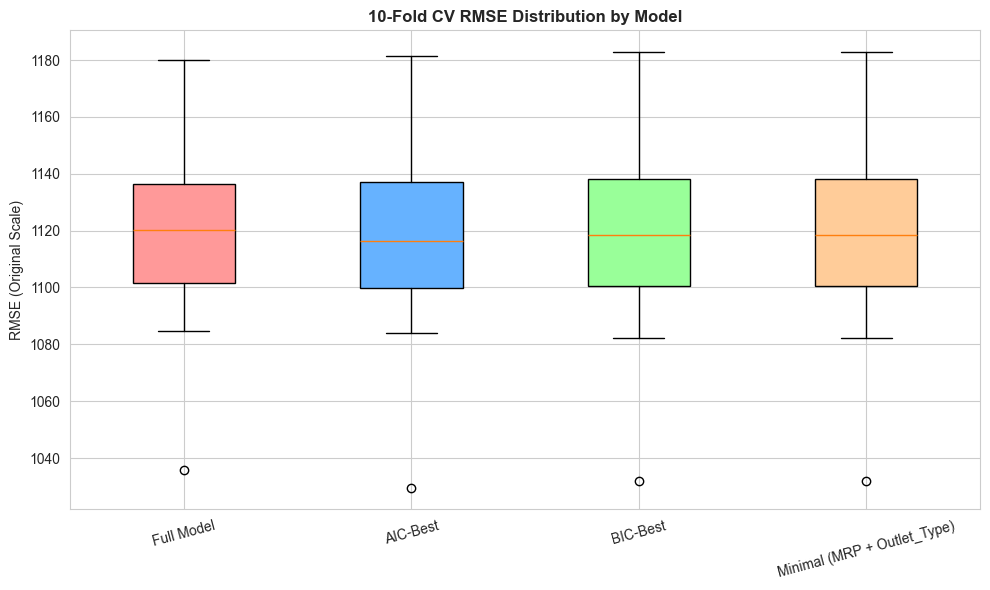

In [21]:
# Visualize CV RMSE distributions
fig, ax = plt.subplots(figsize=(10, 6))
positions = range(len(cv_fold_details))
labels = []
data = []
for name in candidate_models:
    labels.append(name)
    data.append(cv_fold_details[name])

bp = ax.boxplot(data, labels=labels, patch_artist=True)
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_ylabel('RMSE (Original Scale)')
ax.set_title('10-Fold CV RMSE Distribution by Model', fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 5.2 Final Holdout Test Evaluation
We evaluate each candidate on the **completely unseen test set** (20% held out during data preparation). This is the definitive measure of generalization.

In [22]:
# Final test set evaluation
# Transform test target with same lambda used on training
y_test_raw = test_df['Item_Outlet_Sales'].values
test_df['Sales_Transformed'] = (y_test_raw**bc_lambda - 1) / bc_lambda

test_results = []
for name, feats in candidate_models.items():
    formula = make_formula('Sales_Transformed', feats['cont'], feats['cat'])
    model = smf.ols(formula, data=train_df).fit()
    
    # Predict on test set
    y_pred_bc = model.predict(test_df)
    y_pred_original = inv_boxcox(y_pred_bc, bc_lambda)
    
    valid_mask = np.isfinite(y_pred_original) & (y_pred_original > 0)
    rmse = np.sqrt(mean_squared_error(y_test_raw[valid_mask], y_pred_original[valid_mask]))
    r2 = r2_score(y_test_raw[valid_mask], y_pred_original[valid_mask])
    mae = np.mean(np.abs(y_test_raw[valid_mask] - y_pred_original[valid_mask]))
    
    test_results.append({
        'Model': name,
        'Test_RMSE': rmse,
        'Test_R2': r2,
        'Test_MAE': mae,
        'N_valid': valid_mask.sum()
    })

test_df_results = pd.DataFrame(test_results).sort_values('Test_RMSE')
print("=== HOLDOUT TEST SET PERFORMANCE (Original Scale) ===")
display(test_df_results.round(4))

=== HOLDOUT TEST SET PERFORMANCE (Original Scale) ===


,Model,Test_RMSE,Test_R2,Test_MAE,N_valid
1,AIC-Best,1039.1914,0.6027,723.7070,1705
2,BIC-Best,1040.8846,0.6014,726.2423,1705
3,Minimal (MRP + Outlet_Type),1040.8846,0.6014,726.2423,1705
0,Full Model,1041.5164,0.6009,723.5132,1705


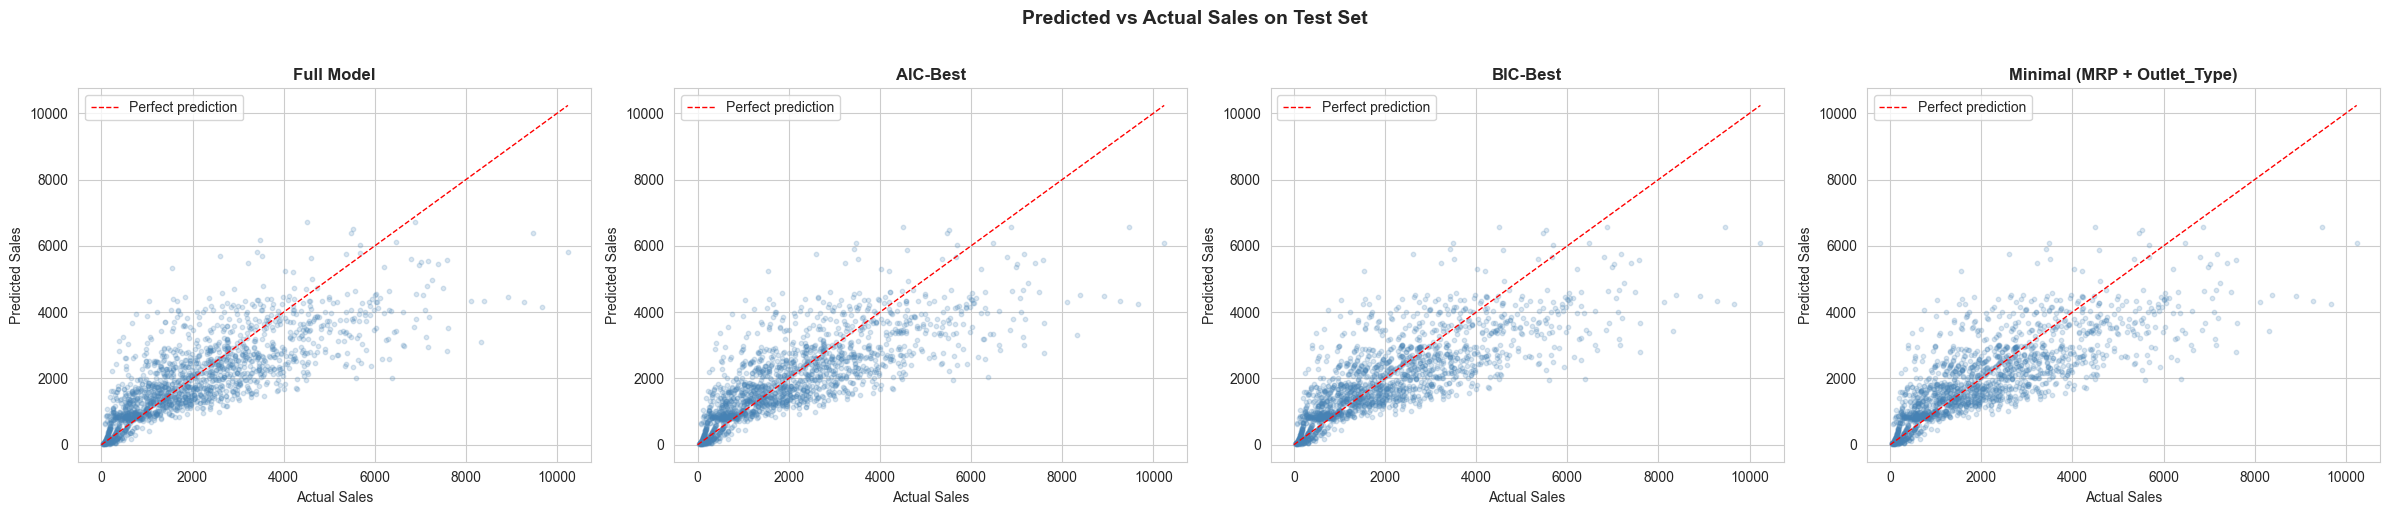

In [23]:
# Predicted vs Actual scatter for each model on test set
fig, axes = plt.subplots(1, len(candidate_models), figsize=(6 * len(candidate_models), 5))

for idx, (name, feats) in enumerate(candidate_models.items()):
    formula = make_formula('Sales_Transformed', feats['cont'], feats['cat'])
    model = smf.ols(formula, data=train_df).fit()
    y_pred_bc = model.predict(test_df)
    y_pred_original = inv_boxcox(y_pred_bc, bc_lambda)
    
    valid_mask = np.isfinite(y_pred_original) & (y_pred_original > 0)
    y_actual = y_test_raw[valid_mask]
    y_pred = y_pred_original[valid_mask]
    
    axes[idx].scatter(y_actual, y_pred, alpha=0.2, s=10, color='steelblue')
    max_val = max(y_actual.max(), y_pred.max())
    axes[idx].plot([0, max_val], [0, max_val], 'r--', linewidth=1, label='Perfect prediction')
    axes[idx].set_xlabel('Actual Sales')
    axes[idx].set_ylabel('Predicted Sales')
    axes[idx].set_title(f'{name}', fontweight='bold')
    axes[idx].legend()

plt.suptitle('Predicted vs Actual Sales on Test Set', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Final Model Selection and Summary

### Decision Framework
We select the final model by weighing evidence from all steps:

| Criterion | What it favors |
|---|---|
| **AIC** | Best prediction accuracy (may include more features) |
| **BIC** | Simplest adequate model (heavier complexity penalty) |
| **Adjusted R²** | Highest penalized variance explained (tends to overfit) |
| **CV RMSE** | Best out-of-sample prediction (gold standard) |
| **Nested F-test** | Whether dropping features causes statistically significant loss |

The **BIC-Best model** is our recommended choice when the criteria diverge, because:
- BIC applies a heavier penalty for complexity than AIC, preferring genuinely simpler models
- BIC is asymptotically consistent (selects the true model as n grows)
- The instructions prioritize explanation alongside prediction
- If the BIC-Best and AIC-Best models have similar CV RMSE, the simpler one (BIC) is preferred by Occam's Razor

In [24]:
# Consolidated comparison table
print("=" * 80)
print("CONSOLIDATED MODEL COMPARISON")
print("=" * 80)

# Merge all metrics
final_comparison = comp_df[['Model', 'N_groups', 'N_params', 'AIC', 'BIC', 'Adj_R2']].copy()
cv_merge = cv_df[['Model', 'CV_RMSE_mean', 'CV_RMSE_std']].copy()
test_merge = test_df_results[['Model', 'Test_RMSE', 'Test_R2']].copy()

final_comparison = final_comparison.merge(cv_merge, on='Model').merge(test_merge, on='Model')
final_comparison = final_comparison.sort_values('CV_RMSE_mean')

display(final_comparison.round(4))

# Identify the recommended model
# Use BIC-best if its CV RMSE is within 1 std of the best CV RMSE
best_cv_rmse = final_comparison['CV_RMSE_mean'].min()
best_cv_std = final_comparison.loc[final_comparison['CV_RMSE_mean'].idxmin(), 'CV_RMSE_std']
bic_row = final_comparison[final_comparison['Model'] == 'BIC-Best']

if len(bic_row) > 0 and bic_row['CV_RMSE_mean'].values[0] <= best_cv_rmse + best_cv_std:
    recommended = 'BIC-Best'
    reason = "BIC-Best has CV RMSE within 1 std of the overall best, and is simpler (Occam's Razor)."
else:
    recommended = final_comparison.iloc[0]['Model']
    reason = "This model has the lowest CV RMSE."

print(f"\nRECOMMENDED MODEL: {recommended}")
print(f"Reason: {reason}")

CONSOLIDATED MODEL COMPARISON


,Model,N_groups,N_params,AIC,BIC,Adj_R2,CV_RMSE_mean,CV_RMSE_std,Test_RMSE,Test_R2
1,AIC-Best,4,9.0,45376.9641,45438.4100,0.6772,1118.2026,41.5556,1039.1914,0.6027
2,BIC-Best,2,5.0,45381.7893,45415.9259,0.6768,1119.1932,41.3373,1040.8846,0.6014
3,Minimal (MRP + Outlet_Type),2,5.0,45381.7893,45415.9259,0.6768,1119.1932,41.3373,1040.8846,0.6014
0,Full Model,9,29.0,45395.0190,45593.0113,0.6773,1119.8121,40.0431,1041.5164,0.6009



RECOMMENDED MODEL: BIC-Best
Reason: BIC-Best has CV RMSE within 1 std of the overall best, and is simpler (Occam's Razor).


In [25]:
# Display the coefficient table of the recommended model
rec_model = fitted_models[recommended]
print(f"=== {recommended} Model: Full OLS Summary ===\n")
print(rec_model.summary())

print(f"\n\n=== Coefficient Table (sorted by absolute effect size) ===")
coef_table = pd.DataFrame({
    'Term': rec_model.params.index,
    'Coefficient': rec_model.params.values,
    'Std Error': rec_model.bse.values,
    'p-value': rec_model.pvalues.values
})
coef_table['|Coef|'] = coef_table['Coefficient'].abs()
coef_table = coef_table.sort_values('|Coef|', ascending=False).drop(columns='|Coef|')
display(coef_table.reset_index(drop=True))

=== BIC-Best Model: Full OLS Summary ===

                            OLS Regression Results                            
Dep. Variable:      Sales_Transformed   R-squared:                       0.677
Model:                            OLS   Adj. R-squared:                  0.677
Method:                 Least Squares   F-statistic:                     3569.
Date:                Sat, 04 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:15:28   Log-Likelihood:                -22686.
No. Observations:                6818   AIC:                         4.538e+04
Df Residuals:                    6813   BIC:                         4.542e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------

,Term,Coefficient,Std Error,p-value
0,C(Outlet_Type)[T.Supermarket Type3],27.335775,0.335783,0.000000e+00
1,C(Outlet_Type)[T.Supermarket Type1],19.689742,0.251385,0.000000e+00
2,C(Outlet_Type)[T.Supermarket Type2],17.441217,0.336860,0.000000e+00
3,Intercept,2.836878,0.294950,9.210128e-22
4,Item_MRP,0.105036,0.001306,0.000000e+00
